## Custom Dataset, DataLoader & Verification (Nick)
This section builds the PyTorch Dataset and DataLoader pipeline using the validated image metadata stored in the SQLite `images` table.

### Import Libraries
Import the libraries needed to load images, split the dataset, create PyTorch datasets/loaders, and verify the data.

In [1]:
from pathlib import Path
from PIL import Image
from collections import Counter

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split

---
### Set Constants from Preprocessing Pipeline
Reuse Deborah’s preprocessing settings so my Dataset/DataLoader pipeline stays consistent with her work.

In [2]:
# Deborah's cleaned output folder
CLEANED_DIR = Path("./data/cleaned")

# Same image size used in Deborah's preprocessing notebook
IMAGE_SIZE = (224, 224)

# Batch size used for model training
BATCH_SIZE = 32

# Reproducibility
RANDOM_SEED = 42

# ImageNet normalization values used by Deborah
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

---
### Set Random Seed
Set a fixed seed so the train/validation/test split can be reproduced by the whole team.

In [3]:
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("Random seed set to:", RANDOM_SEED)

Random seed set to: 42


Without a seed, your split may change every time the notebook runs. With a seed, everyone gets the same split.

---
### Verify Preprocessing (Deborah’s) Cleaned Folder
Confirm that Deborah’s cleaned folder exists and contains class folders.

In [4]:
# Check if cleaned directory exists
print("Cleaned directory exists:", CLEANED_DIR.exists())
print("Cleaned directory path:", CLEANED_DIR)

# List folders inside cleaned directory
class_folders = sorted([folder.name for folder in CLEANED_DIR.iterdir() if folder.is_dir()])

print("Number of folders found:", len(class_folders))
print("Folders found:")
print(class_folders)

Cleaned directory exists: True
Cleaned directory path: data/cleaned
Number of folders found: 29
Folders found:
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


---
### Define Expected Classes
Define the expected ASL classes so the notebook can check if the cleaned folder structure is correct.

In [5]:
# Expected ASL alphabet classes
expected_classes = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ") + ["del", "nothing", "space"]

# Actual class folders found in Deborah's cleaned output
actual_classes = sorted([
    folder.name 
    for folder in CLEANED_DIR.iterdir() 
    if folder.is_dir()
])

missing_classes = sorted(set(expected_classes) - set(actual_classes))
extra_classes = sorted(set(actual_classes) - set(expected_classes))

print("Expected class count:", len(expected_classes))
print("Actual class count:", len(actual_classes))
print("Missing classes:", missing_classes)
print("Extra classes:", extra_classes)

Expected class count: 29
Actual class count: 29
Missing classes: []
Extra classes: []


---
### Define Image Transforms
Reuse Deborah’s train and validation/test transforms, but apply augmentation only to training data.

In [6]:
# Training transform includes augmentation
train_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Validation and test should not use augmentation
val_test_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

Training gets augmentation to help the model generalize. Validation and test should stay clean and consistent so evaluation is fair.

---
### Collect Image Paths and Labels
Scan Deborah’s cleaned folders and collect every image path with its matching class label.

In [7]:
valid_extensions = {".jpg", ".jpeg", ".png"}

# Sort classes so label mapping is consistent
class_names = sorted(expected_classes)

# Create label mappings
class_to_idx = {class_name: idx for idx, class_name in enumerate(class_names)}
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}

samples = []

for class_name in class_names:
    class_folder = CLEANED_DIR / class_name

    # Skip if folder is missing
    if not class_folder.exists():
        print(f"Warning: Missing folder for class {class_name}")
        continue

    for image_path in class_folder.iterdir():
        if image_path.suffix.lower() in valid_extensions:
            label = class_to_idx[class_name]
            samples.append((image_path, label, class_name))

print("Total images collected:", len(samples))
print("Number of classes:", len(class_names))
print("Sample record:", samples[0])

Total images collected: 87000
Number of classes: 29
Sample record: (PosixPath('data/cleaned/A/A25.jpg'), 0, 'A')


This step converts the folder structure into a structured sample list that my custom Dataset can use.

---
### Check Overall Class Distribution
Count how many images exist per class before splitting.

In [9]:
overall_counts = Counter([class_name for _, _, class_name in samples])

overall_distribution_df = pd.DataFrame({
    "class_name": list(overall_counts.keys()),
    "image_count": list(overall_counts.values())
}).sort_values("class_name")

overall_distribution_df

,class_name,image_count
0,A,3000
1,B,3000
2,C,3000
3,D,3000
4,E,3000
5,F,3000
6,G,3000
7,H,3000
8,I,3000
9,J,3000


This tells us whether the dataset is balanced before splitting. Since the class has the same number of images, the model has a fair starting point.

---
### Create Stratified Train/Validation/Test Split
Split the cleaned dataset into separate train, validation, and test sets while preserving class balance.

In [10]:
# Separate sample components
image_paths = [sample[0] for sample in samples]
labels = [sample[1] for sample in samples]
class_labels = [sample[2] for sample in samples]

# First split: 70% train, 30% temporary
train_paths, temp_paths, train_labels, temp_labels, train_class_labels, temp_class_labels = train_test_split(
    image_paths,
    labels,
    class_labels,
    test_size=0.30,
    stratify=labels,
    random_state=RANDOM_SEED
)

# Second split: temporary set becomes 15% validation and 15% test
val_paths, test_paths, val_labels, test_labels, val_class_labels, test_class_labels = train_test_split(
    temp_paths,
    temp_labels,
    temp_class_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=RANDOM_SEED
)

# Recombine into sample lists
train_samples = list(zip(train_paths, train_labels, train_class_labels))
val_samples = list(zip(val_paths, val_labels, val_class_labels))
test_samples = list(zip(test_paths, test_labels, test_class_labels))

print("Train samples:", len(train_samples))
print("Validation samples:", len(val_samples))
print("Test samples:", len(test_samples))
print("Total after split:", len(train_samples) + len(val_samples) + len(test_samples))

Train samples: 60900
Validation samples: 13050
Test samples: 13050
Total after split: 87000


Train, validation, and test samples are now split to 70%, 15%, 15% sharing.

---
### Build Custom ASL Dataset Class
Create a reusable PyTorch Dataset that receives split-specific samples instead of reading the entire cleaned folder each time.

In [11]:
class ASLDataset(Dataset):
    def __init__(self, samples, class_to_idx, transform=None):
        self.samples = samples
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, label, class_name = self.samples[idx]

        # Open image and ensure RGB format
        image = Image.open(image_path).convert("RGB")

        # Apply transform if provided
        if self.transform:
            image = self.transform(image)

        return image, label

The dataset now uses a specific split, it will not accidentally load the entire dataset for train, validation, and test.

---
### Create Dataset Objects
Create separate Dataset objects for train, validation, and test.

In [13]:
train_dataset = ASLDataset(
    samples=train_samples,
    class_to_idx=class_to_idx,
    transform=train_transforms
)

val_dataset = ASLDataset(
    samples=val_samples,
    class_to_idx=class_to_idx,
    transform=val_test_transforms
)

test_dataset = ASLDataset(
    samples=test_samples,
    class_to_idx=class_to_idx,
    transform=val_test_transforms
)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 60900
Validation dataset size: 13050
Test dataset size: 13050


Each Dataset now points to its own split. This prevents data leakage.

---
### Create DataLoaders
Wrap each Dataset in a DataLoader so the model can receive batches of images and labels.

In [18]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 1904
Validation batches: 408
Test batches: 408


Only the training loader should be shuffled. Validation and test loaders should stay ordered for consistent evaluation.

---
### Verify Batch Shape
Confirm that the DataLoader returns image batches in the correct model-ready shape.

In [19]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image data type:", images.dtype)
print("Label data type:", labels.dtype)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Image data type: torch.float32
Label data type: torch.int64


This confirms that images are ready for a CNN model. The format is: batch size, color channels, height, width

---
### Verify Class Mapping
Check that every class is fairly represented in train, validation, and test.

In [20]:
def get_distribution(split_samples):
    counts = Counter([class_name for _, _, class_name in split_samples])
    return counts

train_dist = get_distribution(train_samples)
val_dist = get_distribution(val_samples)
test_dist = get_distribution(test_samples)

distribution_df = pd.DataFrame({
    "class_name": class_names,
    "train": [train_dist[class_name] for class_name in class_names],
    "validation": [val_dist[class_name] for class_name in class_names],
    "test": [test_dist[class_name] for class_name in class_names],
})

distribution_df

,class_name,train,validation,test
0,A,2100,450,450
1,B,2100,450,450
2,C,2100,450,450
3,D,2100,450,450
4,E,2100,450,450
5,F,2100,450,450
6,G,2100,450,450
7,H,2100,450,450
8,I,2100,450,450
9,J,2100,450,450


This proves that the split is balanced. Since the class counts are close across all classes, the model will not be unfairly biased toward one ASL sign.

---
### Verify No Data Leakage
Confirm that no image appears in more than one split.

In [21]:
train_path_set = set([str(path) for path, _, _ in train_samples])
val_path_set = set([str(path) for path, _, _ in val_samples])
test_path_set = set([str(path) for path, _, _ in test_samples])

train_val_overlap = train_path_set.intersection(val_path_set)
train_test_overlap = train_path_set.intersection(test_path_set)
val_test_overlap = val_path_set.intersection(test_path_set)

print("Train-Val overlap:", len(train_val_overlap))
print("Train-Test overlap:", len(train_test_overlap))
print("Val-Test overlap:", len(val_test_overlap))

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


No image appears in more than one split, this means that the model will not be evaluated on images it already saw during training.

---
### Visualize Sample Images from a Batch
Display a few images from the DataLoader to visually confirm that images and labels match.

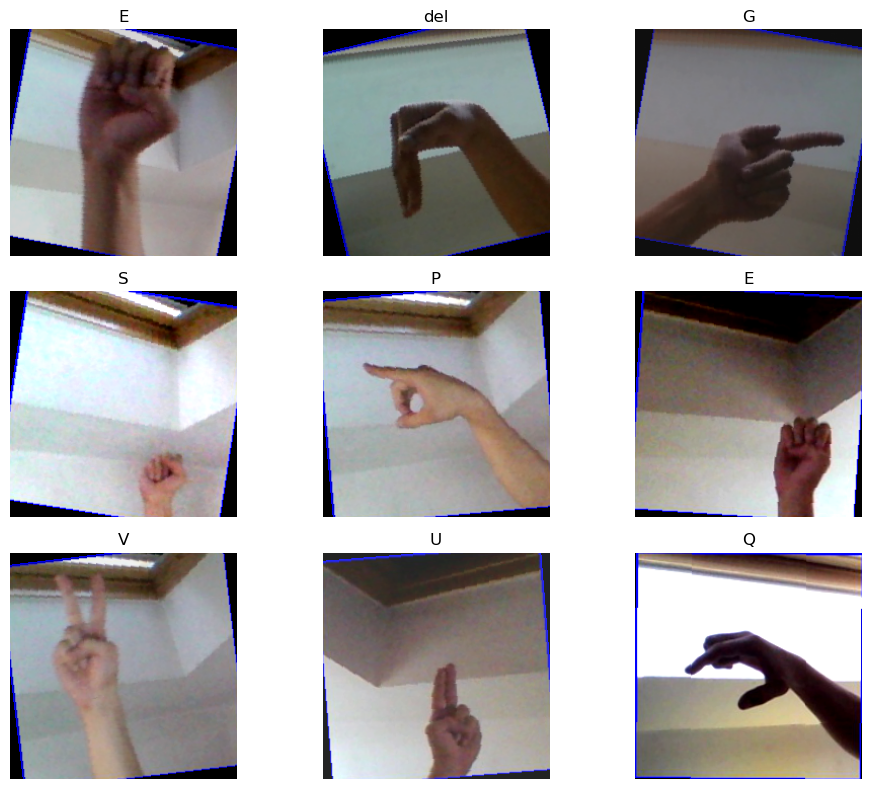

In [22]:
def unnormalize_image(image_tensor):
    # Copy tensor to avoid changing original data
    image = image_tensor.clone().detach()

    # Convert mean and std to tensor format
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    # Reverse normalization
    image = image * std + mean

    # Convert from CHW to HWC for matplotlib
    image = image.permute(1, 2, 0)

    # Keep valid pixel range
    image = image.clamp(0, 1)

    return image


# Get one training batch
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    image = unnormalize_image(images[i])
    label = labels[i].item()
    class_name = idx_to_class[label]

    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

---
### Save Split Metadata
Save the train/validation/test split to a CSV so teammates can reuse the exact same split.

In [23]:
def samples_to_dataframe(samples, split_name):
    return pd.DataFrame({
        "image_path": [str(path) for path, _, _ in samples],
        "label": [label for _, label, _ in samples],
        "class_name": [class_name for _, _, class_name in samples],
        "split": split_name
    })


split_df = pd.concat([
    samples_to_dataframe(train_samples, "train"),
    samples_to_dataframe(val_samples, "validation"),
    samples_to_dataframe(test_samples, "test")
], ignore_index=True)

# Save split file
OUTPUT_SPLIT_PATH = Path("./data/asl_dataset_splits.csv")
split_df.to_csv(OUTPUT_SPLIT_PATH, index=False)

print("Saved split metadata to:", OUTPUT_SPLIT_PATH)
print("Rows saved:", len(split_df))

Saved split metadata to: data/asl_dataset_splits.csv
Rows saved: 87000


---
### Final Verification Summary
Print a simple summary of the completed Dataset/DataLoader pipeline

In [24]:
print("===== Dataset & DataLoader Verification Summary =====")
print("Cleaned data folder:", CLEANED_DIR)
print("Total classes:", len(class_names))
print("Total images:", len(samples))
print()
print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))
print()
print("Batch size:", BATCH_SIZE)
print("Image size:", IMAGE_SIZE)
print("Sample batch shape:", images.shape)
print()
print("Train-Val overlap:", len(train_val_overlap))
print("Train-Test overlap:", len(train_test_overlap))
print("Val-Test overlap:", len(val_test_overlap))
print()
print("Split metadata saved to:", OUTPUT_SPLIT_PATH)

===== Dataset & DataLoader Verification Summary =====
Cleaned data folder: data/cleaned
Total classes: 29
Total images: 87000

Train images: 60900
Validation images: 13050
Test images: 13050

Batch size: 32
Image size: (224, 224)
Sample batch shape: torch.Size([32, 3, 224, 224])

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0

Split metadata saved to: data/asl_dataset_splits.csv


## Summary

This notebook completes the Dataset, DataLoader, and verification stage of the ASL recognition pipeline. It uses the cleaned image output from the preprocessing stage, validates the expected ASL class folder structure, creates a reproducible stratified train/validation/test split, and builds custom PyTorch Dataset and DataLoader objects for each split.

Verification checks confirm that the dataset contains the expected 29 classes, that images are split without overlap, that class distribution is balanced across train/validation/test sets, and that batches are returned in the correct model-ready shape of `[batch_size, 3, 224, 224]`.

A split metadata file is also saved as `data/asl_dataset_splits.csv` so the same dataset split can be reused consistently during model training and evaluation.